In [1]:
import polars as pl
from pathlib import Path

# 1. Загрузка сырых данных (Lazy)
base_dir = Path.cwd()
orders_raw = pl.scan_csv(base_dir / "data.csv")
events_raw = pl.scan_csv(base_dir / "events.csv")

# 2. ОЧИСТКА ОТ ПОВТОРОВ
orders_scan = orders_raw.unique(subset=["order_item_id"])
events_scan = events_raw.unique(subset=["session_id", "created_at", "event_type"])

# 3. РАСЧЕТ ВЕСОВ (Вероятностная модель маржи)
# Вычисляем коэффициент на основе завершенных/отмененных заказов
stats = orders_scan.select([
    pl.col("status").filter(pl.col("status") == "Complete").count().alias("n_complete"),
    pl.col("status").filter(pl.col("status").is_in(["Returned", "Cancelled"])).count().alias("n_failed")
]).collect()

n_complete = stats["n_complete"][0]
n_failed = stats["n_failed"][0]
p_success = n_complete / (n_complete + n_failed) if (n_complete + n_failed) > 0 else 0



print(f"--- Очистка и расчет весов завершены ---")
print(f"Коэффициент ожидаемого успеха (p_success): {p_success:.4f}")

# 4. ПРИМЕНЕНИЕ ВЕСОВ К ORDERS_SCAN
# Теперь 'margin' и 'revenue' во всем коде будут взвешенными
orders_scan = (
    orders_scan
    .with_columns([
        pl.when(pl.col("status") == "Complete").then(pl.lit(1.0))
          .when(pl.col("status").is_in(["Returned", "Cancelled"])).then(pl.lit(0.0))
          .otherwise(pl.lit(p_success))
          .alias("weight")
    ])
    .with_columns([
        ((pl.col("sale_price") - pl.col("cost")) * pl.col("weight")).alias("margin"),
        (pl.col("sale_price") * pl.col("weight")).alias("weighted_revenue")
    ])
)

# 5. АГРЕГАЦИЯ НА УРОВНЕ ЮЗЕРА (для LTV и сегментации)
orders_user_stats = (
    orders_scan
    .with_columns(pl.col("user_id").cast(pl.String)) 
    .group_by("user_id")
    .agg([
        pl.col("weighted_revenue").sum().alias("total_revenue"),
        pl.col("margin").sum().alias("user_lifetime_profit"), # Это и есть наш LTV
        pl.len().alias("total_items_bought"),
        pl.col("order_item_id").n_unique().alias("total_orders")
    ])
)

# 6. ПОДГОТОВКА ИВЕНТОВ И МЕРДЖ
events_prepared = (
    events_scan
    .with_columns([
        pl.col("user_id").min().over("session_id").alias("session_user_id")
    ])
    .with_columns([
        pl.coalesce([pl.col("user_id"), pl.col("session_user_id")]).alias("final_user_id")
    ])
    .filter(pl.col("final_user_id").is_not_null())
)

full_analysis_df = (
    events_prepared
    .join(
        orders_user_stats,
        left_on="final_user_id",
        right_on="user_id",
        how="left"
    )
    .with_columns([
        pl.col("total_revenue").fill_null(0.0),
        pl.col("user_lifetime_profit").fill_null(0.0)
    ])
)

# Проверка результата
res = full_analysis_df.select(["final_user_id", "total_revenue", "user_lifetime_profit"]).head(5).collect()
print("\n--- ПРОВЕРКА ВЗВЕШЕННЫХ ПОКАЗАТЕЛЕЙ (LTV) ---")
print(res)

--- Очистка и расчет весов завершены ---
Коэффициент ожидаемого успеха (p_success): 0.4978

--- ПРОВЕРКА ВЗВЕШЕННЫХ ПОКАЗАТЕЛЕЙ (LTV) ---
shape: (5, 3)
┌───────────────┬───────────────┬──────────────────────┐
│ final_user_id ┆ total_revenue ┆ user_lifetime_profit │
│ ---           ┆ ---           ┆ ---                  │
│ str           ┆ f64           ┆ f64                  │
╞═══════════════╪═══════════════╪══════════════════════╡
│ 42103         ┆ 238.161021    ┆ 128.362971           │
│ 19775         ┆ 38.613885     ┆ 21.948015            │
│ 63823         ┆ 51.496024     ┆ 24.114401            │
│ 10676         ┆ 17.397643     ┆ 8.664026             │
│ 37107         ┆ 237.464804    ┆ 123.979168           │
└───────────────┴───────────────┴──────────────────────┘


In [2]:
import polars as pl

# 1. Проверка ORDERS (Транзакции)
orders_diag = orders_scan.select([
    pl.len().alias("total_rows"),
    pl.col("order_item_id").n_unique().alias("unique_orders"),
    pl.struct(pl.all()).n_unique().alias("total_unique_rows")
]).collect()

# 2. Проверка EVENTS (Логи)
events_diag = events_scan.select([
    pl.len().alias("total_rows"),
    pl.struct(pl.all()).n_unique().alias("total_unique_rows"),
    # Проверка специфических дублей: один юзер, одно время, один тип
    pl.struct(["session_id", "created_at", "event_type"]).n_unique().alias("unique_event_keys")
]).collect()

print("--- Диагностика ORDERS ---")
print(f"Всего строк: {orders_diag['total_rows'][0]}")
print(f"Уникальных order_id: {orders_diag['unique_orders'][0]}")
print(f"Полных дублей строк: {orders_diag['total_rows'][0] - orders_diag['total_unique_rows'][0]}")

print("\n--- Диагностика EVENTS ---")
print(f"Всего строк: {events_diag['total_rows'][0]}")
print(f"Полных дублей строк: {events_diag['total_rows'][0] - events_diag['total_unique_rows'][0]}")
print(f"Технических повторов (ключ сессия+время+тип): {events_diag['total_rows'][0] - events_diag['unique_event_keys'][0]}")

--- Диагностика ORDERS ---
Всего строк: 181926
Уникальных order_id: 181926
Полных дублей строк: 0

--- Диагностика EVENTS ---
Всего строк: 2432662
Полных дублей строк: 0
Технических повторов (ключ сессия+время+тип): 0


In [3]:
# В конце блока №4
orders_scan = orders_scan.drop(["sale_price", "cost"])

In [4]:

# 2. ПОДГОТОВКА ИВЕНТОВ (Восстановление ID и фильтрация уникальных)
events_filled = (
    events_scan
    .unique(subset=["session_id", "created_at", "event_type"])
    .with_columns(
        filled_user_id = pl.col("user_id").min().over("session_id")
    )
    .with_columns(
        final_user_id = pl.coalesce([pl.col("user_id"), pl.col("filled_user_id")])
    )
)

# 3. АГРЕГАЦИЯ ФИНАНСОВ (Из таблицы заказов)
orders_stats = (
    orders_scan
    .with_columns(pl.col("user_id").cast(pl.String)) 
    .group_by("user_id")
    .agg([
        # Используем weighted_revenue вместо sale_price
        pl.col("weighted_revenue").sum().alias("total_revenue"),
        # Используем margin (уже взвешенную) вместо суммы cost
        pl.col("margin").sum().alias("total_margin") 
    ])
)

# 4. СЕГМЕНТАЦИЯ ПОЛЬЗОВАТЕЛЕЙ
user_segments = (
    events_filled
    .filter(pl.col("final_user_id").is_not_null())
    .group_by("final_user_id")
    .agg(pl.col("session_id").n_unique().alias("sessions_count"))
    .join(orders_stats, left_on="final_user_id", right_on="user_id", how="left")
    .with_columns([
        pl.col("total_revenue").fill_null(0.0),
        pl.when(pl.col("sessions_count") == 1).then(pl.lit("One-timer"))
          .when(pl.col("sessions_count") <= 3).then(pl.lit("Regular"))
          .otherwise(pl.lit("Heavy User"))
          .alias("user_type")
    ])
)

# 5. ПОДГОТОВКА СОБЫТИЙ С МЕТКАМИ СЕГМЕНТОВ
events_with_seg = (
    events_filled
    .join(user_segments.select(["final_user_id", "user_type"]), on="final_user_id", how="inner")
)

# 6. ФУНКЦИЯ РАСЧЕТА МЕТРИК (Исправленная логика CR)
def get_segmented_metrics(df_events, segment_name):
    # А) Данные по всему сегменту (база для ARPU и CR)
    seg_summary = (
        user_segments
        .filter(pl.col("user_type") == segment_name)
        .select([
            pl.len().alias("total_users"),
            pl.col("total_revenue").sum().alias("rev"),
            pl.col("sessions_count").sum().alias("sess")
        ])
        .collect()
    )
    
    n_users = seg_summary["total_users"][0]
    total_rev = seg_summary["rev"][0]
    total_sess = seg_summary["sess"][0]
    
    # Б) Считаем только тех, кто совершил покупку в этом сегменте
    # Используем уникальных пользователей, чтобы CR не раздувался от повторных покупок
    purchase_users = (
        df_events
        .filter((pl.col("user_type") == segment_name) & (pl.col("event_type") == "purchase"))
        .select(pl.col("final_user_id").n_unique())
        .collect()
        .item()
    )

    return pl.DataFrame({
        "segment": [segment_name],
        "conversion_to_purchase": [round(purchase_users / n_users, 4) if n_users > 0 else 0],
        "ARPU": [round(total_rev / n_users, 2) if n_users > 0 else 0],
        "ARPS": [round(total_rev / total_sess, 2) if total_sess > 0 else 0],
        "users_count": [n_users]
    })

# 7. СБОРКА И ВЫВОД
final_report = pl.concat([
    get_segmented_metrics(events_with_seg, s) 
    for s in ["One-timer", "Regular", "Heavy User"]
])

print("--- ИТОГОВЫЙ ОТЧЕТ: КОРРЕКТНАЯ КОНВЕРСИЯ И ЭКОНОМИКА ---")
print(final_report.sort("ARPU", descending=True))

--- ИТОГОВЫЙ ОТЧЕТ: КОРРЕКТНАЯ КОНВЕРСИЯ И ЭКОНОМИКА ---
shape: (3, 5)
┌────────────┬────────────────────────┬────────┬───────┬─────────────┐
│ segment    ┆ conversion_to_purchase ┆ ARPU   ┆ ARPS  ┆ users_count │
│ ---        ┆ ---                    ┆ ---    ┆ ---   ┆ ---         │
│ str        ┆ f64                    ┆ f64    ┆ f64   ┆ i64         │
╞════════════╪════════════════════════╪════════╪═══════╪═════════════╡
│ Heavy User ┆ 1.0                    ┆ 149.75 ┆ 29.76 ┆ 15530       │
│ Regular    ┆ 1.0                    ┆ 69.67  ┆ 29.86 ┆ 29471       │
│ One-timer  ┆ 1.0                    ┆ 29.13  ┆ 29.13 ┆ 35020       │
└────────────┴────────────────────────┴────────┴───────┴─────────────┘


In [5]:
# Агрегируем поведенческие метрики по сегментам
session_analysis = (
    events_with_seg
    .group_by("user_type")
    .agg([
        # Среднее кол-во событий (кликов) на сессию
        (pl.len() / pl.col("session_id").n_unique()).alias("avg_clicks_in_session"),
        # Конверсия сессии
        (pl.col("event_type").filter(pl.col("event_type") == "purchase").count() / 
         pl.col("session_id").n_unique()).alias("session_conversion_rate")
    ])
)

# Агрегируем финансовые плотности
finance_density = (
    user_segments
    .group_by("user_type")
    .agg([
        (pl.col("sessions_count").mean()).alias("avg_sessions_per_user"),
        (pl.col("total_revenue").sum() / pl.col("sessions_count").sum()).alias("avg_arps_check"),
        (pl.col("total_revenue").mean()).alias("avg_ltv")
    ])
)

# Теперь ваш код с джойном отработает корректно
check_report_df = (
    session_analysis
    .join(finance_density, on="user_type")
    .sort("avg_ltv") 
    .select([
        "user_type",
        pl.col("avg_clicks_in_session").round(2).alias("Сложность сессии (клики)"),
        pl.col("session_conversion_rate").round(4).alias("CR сессии (реальный)"),
        pl.col("avg_sessions_per_user").round(2).alias("Частота визитов"),
        pl.col("avg_arps_check").round(2).alias("Выхлоп с сессии (ARPS)"),
        pl.col("avg_ltv").round(2).alias("Ценность юзера (LTV)")
    ])
    .collect()
)

In [6]:
import polars as pl

# Считаем итоговый отчет
check_report_df = (
    session_analysis
    .join(finance_density, on="user_type")
    # Сортируем ДО селекта и переименования, пока колонка еще называется avg_ltv
    .sort("avg_ltv") 
    .select([
        "user_type",
        pl.col("avg_clicks_in_session").round(2).alias("Сложность сессии (клики)"),
        pl.col("session_conversion_rate").round(4).alias("CR сессии (реальный)"),
        pl.col("avg_sessions_per_user").round(2).alias("Частота визитов"),
        pl.col("avg_arps_check").round(2).alias("Выхлоп с сессии (ARPS)"),
        pl.col("avg_ltv").round(2).alias("Ценность юзера (LTV)")
    ])
    .collect()
)

print("--- ПРОВЕРКА ГИПОТЕЗЫ: АНАЛИЗ ПОВЕДЕНЧЕСКОЙ ЭНТРОПИИ ---")
print(check_report_df)

--- ПРОВЕРКА ГИПОТЕЗЫ: АНАЛИЗ ПОВЕДЕНЧЕСКОЙ ЭНТРОПИИ ---
shape: (3, 6)
┌────────────┬─────────────────┬────────────────┬────────────────┬────────────────┬────────────────┐
│ user_type  ┆ Сложность       ┆ CR сессии      ┆ Частота        ┆ Выхлоп с       ┆ Ценность юзера │
│ ---        ┆ сессии (клики)  ┆ (реальный)     ┆ визитов        ┆ сессии (ARPS)  ┆ (LTV)          │
│ str        ┆ ---             ┆ ---            ┆ ---            ┆ ---            ┆ ---            │
│            ┆ f64             ┆ f64            ┆ f64            ┆ f64            ┆ f64            │
╞════════════╪═════════════════╪════════════════╪════════════════╪════════════════╪════════════════╡
│ One-timer  ┆ 5.0             ┆ 1.0            ┆ 1.0            ┆ 29.13          ┆ 29.13          │
│ Regular    ┆ 6.46            ┆ 1.0            ┆ 2.33           ┆ 29.86          ┆ 69.67          │
│ Heavy User ┆ 8.82            ┆ 1.0            ┆ 5.03           ┆ 29.76          ┆ 149.75         │
└────────────┴──────

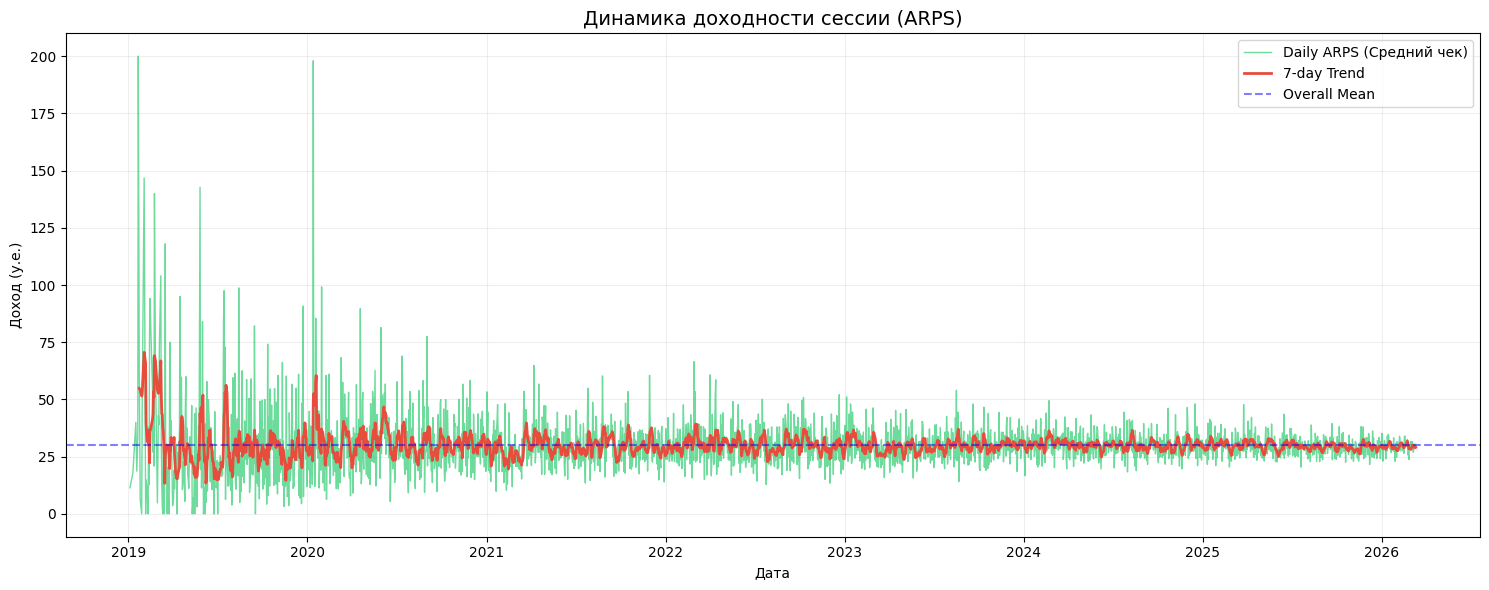

Средний ARPS по системе: 29.88


In [7]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Считаем данные, обрезая строку до даты (метод "с плеча")
orders_daily = (
    orders_scan
    .with_columns(
        # Берем первые 10 символов '2022-12-27', игнорируя всё остальное
        date = pl.col("created_at").str.slice(0, 10).str.to_datetime("%Y-%m-%d").dt.date()
    )
    .group_by("date")
    .agg([
        pl.col("weighted_revenue").sum().alias("daily_revenue"),
        pl.col("order_item_id").n_unique().alias("daily_orders")
    ])
    .with_columns(
        arps_t = pl.col("daily_revenue") / pl.col("daily_orders")
    )
    .sort("date")
    .collect()
)

# 2. Визуализация
plt.figure(figsize=(15, 6))

# Подготовка данных для matplotlib (через списки для надежности)
x = orders_daily["date"].to_list()
y = orders_daily["arps_t"].to_list()

plt.plot(x, y, label="Daily ARPS (Средний чек)", color="#2ecc71", linewidth=1, alpha=0.7)

# Добавляем скользящее среднее для тренда
y_smooth = orders_daily["arps_t"].rolling_mean(window_size=7).to_list()
plt.plot(x, y_smooth, label="7-day Trend", color="#e74c3c", linewidth=2)

# Оформление
plt.title("Динамика доходности сессии (ARPS)", fontsize=14)
plt.xlabel("Дата")
plt.ylabel("Доход (у.е.)")
plt.axhline(orders_daily["arps_t"].mean(), color='blue', linestyle='--', alpha=0.5, label="Overall Mean")
plt.grid(True, alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Средний ARPS по системе: {orders_daily['arps_t'].mean():.2f}")

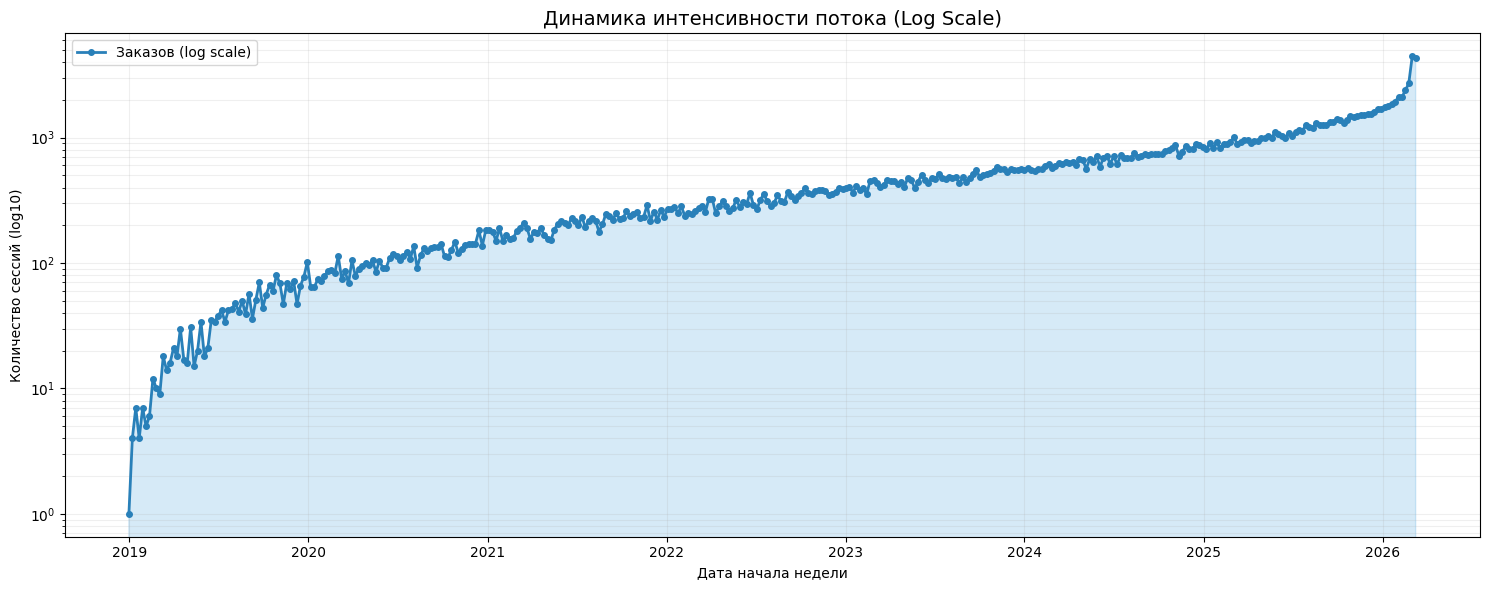

Средняя нагрузка: 484 сессий/нед


In [8]:
import matplotlib.pyplot as plt
import polars as pl

# 1. Агрегируем сессии по неделям (код без изменений)
sessions_weekly = (
    orders_scan
    .with_columns(
        date = pl.col("created_at").str.slice(0, 10).str.to_datetime("%Y-%m-%d").dt.date()
    )
    .sort("date") 
    .group_by_dynamic("date", every="1w")
    .agg([
        pl.col("order_item_id").n_unique().alias("weekly_sessions")
    ])
    .collect()
)

# 2. Строим график в LOG масштабе
plt.figure(figsize=(15, 6))

x = sessions_weekly["date"].to_list()
y = sessions_weekly["weekly_sessions"].to_list()

# Используем step или обычный plot, на лог-шкале бары иногда выглядят громоздко
plt.plot(x, y, color="#2980b9", marker='o', markersize=4, linewidth=2, label="Заказов (log scale)")
plt.fill_between(x, y, color="#3498db", alpha=0.2)

# ВКЛЮЧАЕМ ЛОГАРИФМИЧЕСКУЮ ШКАЛУ
plt.yscale('log')

plt.title("Динамика интенсивности потока (Log Scale)", fontsize=14)
plt.xlabel("Дата начала недели")
plt.ylabel("Количество сессий (log10)")
plt.grid(True, which="both", ls="-", alpha=0.2) # 'both' покажет сетку и для доп. делений логарифма
plt.legend()
plt.tight_layout()
plt.show()

print(f"Средняя нагрузка: {sessions_weekly['weekly_sessions'].mean():.0f} сессий/нед")

In [9]:
# 1. Агрегируем сессии по неделям
sessions_weekly = (
    orders_scan
    .with_columns(
        date = pl.col("created_at").str.slice(0, 10).str.to_datetime("%Y-%m-%d").dt.date()
    )
    .sort("date") 
    .group_by_dynamic("date", every="1w")
    .agg([
        pl.col("order_item_id").n_unique().alias("weekly_sessions")
    ])
    .collect()
)

# 2. Сохранение данных в CSV
sessions_weekly.write_csv("sessions_weekly_stats.csv")

print("Данные успешно сохранены в файл: sessions_weekly_stats.csv")

# Далее следует ваш код визуализации (plt.figure...)

Данные успешно сохранены в файл: sessions_weekly_stats.csv


In [10]:
import polars as pl
import plotly.express as px

# 1. Корректная агрегация: группируем ТОЛЬКО по городу
city_geo_stats_cleaned = (
    orders_scan
    # УДАЛИТЬ: .with_columns([(pl.col("sale_price") - pl.col("cost")).alias("margin")]) 
    .group_by("city")
    .agg([
        pl.col("margin").sum().alias("total_margin"), # Используется взвешенная маржа
        pl.col("weighted_revenue").sum().alias("total_revenue"), # Исправлено
        pl.col("order_item_id").n_unique().alias("orders_count"),
        pl.col("delivery_latitude").mean().alias("lat"),
        pl.col("delivery_longitude").mean().alias("lon")
    ])
    .filter(
        pl.col("city").is_not_null() & 
        pl.col("lat").is_not_null()
    )
    .sort("total_margin", descending=True)
    .collect()
)

# 2. Отрисовка обновленных данных
fig = px.scatter_geo(
    city_geo_stats_cleaned.to_pandas(),
    lat="lat",
    lon="lon",
    size="total_margin",
    hover_name="city",
    size_max=40,
    color="total_margin",
    color_continuous_scale="Viridis",
    title="Скорректированная география маржи (центроиды городов)",
    projection="mercator",
    # Добавим отображение количества заказов в тултип
    hover_data={
        "lat": False, 
        "lon": False, 
        "total_margin": ":.2f",
        "orders_count": True
    }
)

fig.update_layout(
    geo=dict(
        showcountries=True,
        showland=True,
        landcolor="GhostWhite",
        countrycolor="Silver"
    ),
    height=750
)

fig.show()

# Вывод для проверки "чистоты" данных
print("--- ТОП-10 городов (корректная сумма) ---")
print(city_geo_stats_cleaned.head(10))

--- ТОП-10 городов (корректная сумма) ---
shape: (10, 6)
┌──────────┬──────────────┬───────────────┬──────────────┬───────────┬────────────┐
│ city     ┆ total_margin ┆ total_revenue ┆ orders_count ┆ lat       ┆ lon        │
│ ---      ┆ ---          ┆ ---           ┆ ---          ┆ ---       ┆ ---        │
│ str      ┆ f64          ┆ f64           ┆ u32          ┆ f64       ┆ f64        │
╞══════════╪══════════════╪═══════════════╪══════════════╪═══════════╪════════════╡
│ Shanghai ┆ 67853.220647 ┆ 130343.223025 ┆ 4435         ┆ 32.658431 ┆ 115.907802 │
│ Beijing  ┆ 57524.062732 ┆ 111686.514139 ┆ 3775         ┆ 31.566993 ┆ 114.292338 │
│ Seoul    ┆ 42042.6617   ┆ 80855.861481  ┆ 2677         ┆ 37.551521 ┆ 126.994543 │
│ Shenzhen ┆ 38042.637588 ┆ 72874.132789  ┆ 2359         ┆ 31.218298 ┆ 114.14559  │
│ null     ┆ 28819.578987 ┆ 56185.929404  ┆ 1818         ┆ 3.60686   ┆ -44.659593 │
│ Dongguan ┆ 25739.459404 ┆ 50133.499066  ┆ 1753         ┆ 30.341192 ┆ 116.777885 │
│ Wuhan    ┆ 24482.

In [14]:
import polars as pl
from pathlib import Path

# 1. Создаем директорию для результатов
output_dir = Path("margin_by_continents")
output_dir.mkdir(exist_ok=True)

# 2. Определяем границы континентов (Bounding Boxes)
continents_geom = {
    "North_America": (7.0, 85.0, -170.0, -50.0),
    "South_America": (-56.0, 7.0, -93.0, -32.0),
    "Europe": (35.0, 82.0, -25.0, 40.0),
    "Asia": (-10.0, 82.0, 40.0, 180.0),
    "Africa": (-35.0, 35.0, -20.0, 52.0),
    "Oceania": (-50.0, -10.0, 110.0, 180.0)
}

# 3. Подготовка данных
base_data = (
    orders_scan
    .filter(pl.col("delivery_latitude").is_not_null() & pl.col("city").is_not_null())
    .select([
        pl.col("city"),
        pl.col("delivery_latitude").alias("lat"),
        pl.col("delivery_longitude").alias("lon"),
        pl.col("margin"),
        pl.col("order_item_id")
    ])
    .collect()
)

print("--- Распределение по континентам (Top 60% Margin) ---")

for cont, (lat_min, lat_max, lon_min, lon_max) in continents_geom.items():
    # Фильтрация и агрегация по городам
    cont_df = (
        base_data
        .filter(
            (pl.col("lat").is_between(lat_min, lat_max)) &
            (pl.col("lon").is_between(lon_min, lon_max))
        )
        .group_by("city")
        .agg([
            pl.col("margin").sum().alias("total_margin"),
            pl.col("order_item_id").n_unique().alias("orders_count"),
            pl.col("lat").mean(),
            pl.col("lon").mean()
        ])
        .sort("total_margin", descending=True)
    )
    
    if not cont_df.is_empty():
        # Вычисление порога в 60% от суммарной маржи континента
        total_cont_margin = cont_df["total_margin"].sum()
        threshold = total_cont_margin * 0.6
        
        # Фильтрация: оставляем города, входящие в топ-60% кумулятивной маржи
        cont_df = (
            cont_df
            .with_columns(cum_margin=pl.col("total_margin").cum_sum())
            .filter(pl.col("cum_margin").shift(1, fill_value=0) < threshold)
            .drop("cum_margin")
        )
        
        if not cont_df.is_empty():
            file_path = output_dir / f"{cont}_margin.csv"
            cont_df.select(["city", "total_margin", "orders_count", "lat", "lon"]).write_csv(file_path)
            
            margin_sum = cont_df["total_margin"].sum()
            print(f"{cont:15}: Сохранено {len(cont_df)} городов (целевой сегмент). Суммарная маржа сегмента: {margin_sum:.2f}")
    else:
        print(f"{cont:15}: Данные отсутствуют в указанных границах")

print(f"\nЭкспорт завершен. Данные сохранены в: {output_dir.absolute()}")

--- Распределение по континентам (Top 60% Margin) ---
North_America  : Сохранено 426 городов (целевой сегмент). Суммарная маржа сегмента: 374646.98
South_America  : Сохранено 147 городов (целевой сегмент). Суммарная маржа сегмента: 243585.91
Europe         : Сохранено 584 городов (целевой сегмент). Суммарная маржа сегмента: 322606.88
Asia           : Сохранено 44 городов (целевой сегмент). Суммарная маржа сегмента: 700562.14
Africa         : Сохранено 6 городов (целевой сегмент). Суммарная маржа сегмента: 2298.40
Oceania        : Сохранено 16 городов (целевой сегмент). Суммарная маржа сегмента: 38662.47

Экспорт завершен. Данные сохранены в: c:\Users\Fonon\Desktop\Хактатон_2026 МФТИ\margin_by_continents


In [12]:
import polars as pl
import plotly.express as px

# 1. Агрегация данных по городам
# 1. Агрегация данных по городам (Корректная версия)
city_distribution = (
    orders_scan
    # УДАЛЕНО: расчет margin через sale_price и cost
    .group_by("city")
    .agg(pl.col("margin").sum().alias("total_margin"))
    .filter(pl.col("city").is_not_null())
    .sort("total_margin", descending=True)
    .collect()
)

# 2. Визуализация распределения (Топ-30 городов)
top_n = 30
fig = px.bar(
    city_distribution.head(top_n).to_pandas(),
    x="city",
    y="total_margin",
    color="total_margin",
    title=f"Топ-{top_n} городов по суммарной марже",
    labels={"city": "Город", "total_margin": "Суммарная маржа ($)"},
    color_continuous_scale="Viridis"
)

fig.update_layout(
    xaxis_tickangle=-45,
    xaxis_title=None,
    height=600,
    template="plotly_white"
)

fig.show()

# 3. Анализ концентрации (Принцип Парето)
total_margin_sum = city_distribution["total_margin"].sum()
top_10_sum = city_distribution["total_margin"].head(10).sum()

print(f"Общая маржа по всем городам: {total_margin_sum:,.2f}")
print(f"Доля топ-10 городов в общей марже: {(top_10_sum / total_margin_sum):.1%}")

Общая маржа по всем городам: 2,801,811.65
Доля топ-10 городов в общей марже: 12.6%


In [13]:
# 1. Расчет долей и кумулятивной суммы
city_pareto = (
    city_distribution
    .with_columns([
        # Относительная доля каждого города
        (pl.col("total_margin") / pl.col("total_margin").sum()).alias("margin_share")
    ])
    .with_columns([
        # Накопительный итог (интеграл по отсортированному массиву)
        pl.col("margin_share").cum_sum().alias("cumulative_share")
    ])
)

# 2. Сохранение в файл
city_pareto.write_csv("city_margin_pareto.csv")

# Вывод первых строк для верификации структуры
print("--- ФРАГМЕНТ ПАРЕТО-АНАЛИЗА ---")
print(city_pareto.head(10))

--- ФРАГМЕНТ ПАРЕТО-АНАЛИЗА ---
shape: (10, 4)
┌──────────┬──────────────┬──────────────┬──────────────────┐
│ city     ┆ total_margin ┆ margin_share ┆ cumulative_share │
│ ---      ┆ ---          ┆ ---          ┆ ---              │
│ str      ┆ f64          ┆ f64          ┆ f64              │
╞══════════╪══════════════╪══════════════╪══════════════════╡
│ Shanghai ┆ 67853.220647 ┆ 0.024218     ┆ 0.024218         │
│ Beijing  ┆ 57524.062732 ┆ 0.020531     ┆ 0.044749         │
│ Seoul    ┆ 42042.6617   ┆ 0.015006     ┆ 0.059754         │
│ Shenzhen ┆ 38042.637588 ┆ 0.013578     ┆ 0.073332         │
│ null     ┆ 28819.578987 ┆ 0.010286     ┆ 0.083618         │
│ Dongguan ┆ 25739.459404 ┆ 0.009187     ┆ 0.092805         │
│ Wuhan    ┆ 24482.953215 ┆ 0.008738     ┆ 0.101543         │
│ New York ┆ 23398.239432 ┆ 0.008351     ┆ 0.109894         │
│ Tokyo    ┆ 23303.381371 ┆ 0.008317     ┆ 0.118211         │
│ Chengdu  ┆ 22494.954545 ┆ 0.008029     ┆ 0.12624          │
└──────────┴───────────

In [14]:
import plotly.figure_factory as ff
import numpy as np

# 1. Подготовка данных: берем вектор маржи по городам
margin_vector = city_distribution["total_margin"].to_list()

# 2. Построение гистограммы распределения
# Группируем данные, чтобы увидеть форму распределения
fig = ff.create_distplot(
    [margin_vector], 
    group_labels=['Margin Distribution'],
    bin_size=100000, # Размер корзины можно варьировать для сглаживания
    curve_type='kde', # Линия оценки плотности ядра
    colors=['#3366CC']
)

fig.update_layout(
    title_text='Анализ формы распределения маржи по городам',
    xaxis_title='Суммарная маржа в городе ($)',
    yaxis_title='Плотность (Density)',
    template='plotly_white',
    showlegend=False
)

fig.show()

# 3. Краткий статистический тест на "нормальность"
mean_val = np.mean(margin_vector)
median_val = np.median(margin_vector)
std_val = np.std(margin_vector)

print(f"--- Статистические моменты ---")
print(f"Среднее (Mean):   {mean_val:,.2f}")
print(f"Медиана (Median): {median_val:,.2f}")
print(f"СКО (Std Dev):    {std_val:,.2f}")

if mean_val > median_val * 1.5:
    print("\nДиагноз: Распределение имеет сильную положительную асимметрию (Long Tail).")
    print("Это не Гауссиана. Скорее всего, это Логнормальное распределение или закон Парето.")
else:
    print("\nДиагноз: Распределение симметрично, форма близка к нормальной.")

--- Статистические моменты ---
Среднее (Mean):   368.08
Медиана (Median): 113.04
СКО (Std Dev):    1,734.61

Диагноз: Распределение имеет сильную положительную асимметрию (Long Tail).
Это не Гауссиана. Скорее всего, это Логнормальное распределение или закон Парето.


In [15]:
import polars as pl
import plotly.express as px

# 1. Агрегация данных
city_geo_stats_cleaned = (
    orders_scan
    # УДАЛИТЬ: .with_columns([(pl.col("sale_price") - pl.col("cost")).alias("margin")]) 
    .group_by("city")
    .agg([
        pl.col("margin").sum().alias("total_margin"), # Используется взвешенная маржа
        pl.col("weighted_revenue").sum().alias("total_revenue"), # Исправлено
        pl.col("order_item_id").n_unique().alias("orders_count"),
        pl.col("delivery_latitude").mean().alias("lat"),
        pl.col("delivery_longitude").mean().alias("lon")
    ])
    .filter(
        (pl.col("city").is_not_null()) & 
        (pl.col("lat").is_not_null()) &
        (pl.col("total_margin") > 0) # Фокусируемся на прибыльных локациях
    )
    .with_columns([
        (pl.col("total_margin") / pl.col("orders_count")).alias("margin_per_order"),
        (pl.col("total_margin") / pl.col("total_revenue")).alias("profit_margin_ratio")
    ])
    .sort("total_margin", descending=True)
    .collect()
)

# 2. Отрисовка: Цвет — Маржа за заказ
fig = px.scatter_geo(
    city_geo_stats_cleaned.to_pandas(),
    lat="lat",
    lon="lon",
    size="total_margin",           # Масса прибыли
    color="margin_per_order",      # Интенсивность (профит с одного заказа)
    hover_name="city",
    size_max=35,
    # Шкала 'Plasma' или 'Turbo' часто лучше подсвечивает градиент интенсивности
    color_continuous_scale="Plasma", 
    title="География прибыли: Размер — Total Margin, Цвет — Margin per Order",
    projection="mercator",
    hover_data={
        "lat": False, 
        "lon": False, 
        "total_margin": ":,.2f",
        "orders_count": True,
        "margin_per_order": ":,.2f",
        "profit_margin_ratio": ":.2%"
    }
)

fig.update_layout(
    geo=dict(
        showcountries=True,
        showland=True,
        landcolor="#f9f9f9",
        countrycolor="#d1d1d1",
        coastlinecolor="#d1d1d1"
    ),
    margin={"r":0,"t":50,"l":0,"b":0},
    height=800
)

fig.show()

# Аналитический срез по марже за заказ
print("--- ТОП-10 городов по эффективности (Margin per Order) ---")
print(
    city_geo_stats_cleaned
    .filter(pl.col("orders_count") > 10) # Исключаем города с единичными заказами
    .sort("margin_per_order", descending=True)
    .select(["city", "margin_per_order", "total_margin", "orders_count"])
    .head(10)
)

--- ТОП-10 городов по эффективности (Margin per Order) ---
shape: (10, 4)
┌────────────────────┬──────────────────┬──────────────┬──────────────┐
│ city               ┆ margin_per_order ┆ total_margin ┆ orders_count │
│ ---                ┆ ---              ┆ ---          ┆ ---          │
│ str                ┆ f64              ┆ f64          ┆ u32          │
╞════════════════════╪══════════════════╪══════════════╪══════════════╡
│ Glendale Heights   ┆ 67.259925        ┆ 739.85918    ┆ 11           │
│ Bad Segeberg       ┆ 58.084785        ┆ 638.932638   ┆ 11           │
│ Jeremoabo          ┆ 53.699068        ┆ 698.08789    ┆ 13           │
│ Fronton            ┆ 53.191128        ┆ 851.058049   ┆ 16           │
│ Annonay            ┆ 52.004448        ┆ 624.053371   ┆ 12           │
│ Smithtown          ┆ 46.126196        ┆ 645.766742   ┆ 14           │
│ Rockville Centre   ┆ 45.056002        ┆ 630.784028   ┆ 14           │
│ Welwyn Garden City ┆ 44.161744        ┆ 574.102676   ┆ 13   

In [16]:
import polars as pl
import plotly.express as px

# 1. Агрегация (без изменений)
city_returns_stats = (
    orders_scan
    .group_by("city")
    .agg([
        pl.col("order_item_id").n_unique().alias("total_orders"),
        pl.col("order_item_id")
          .filter(pl.col("returned_at").is_not_null())
          .n_unique()
          .alias("returns_count"),
        pl.col("delivery_latitude").mean().alias("lat"),
        pl.col("delivery_longitude").mean().alias("lon")
    ])
    .filter(
        (pl.col("city").is_not_null()) & 
        (pl.col("lat").is_not_null()) &
        (pl.col("lat") != 0) &
        (pl.col("total_orders") > 10)
    )
    .with_columns([
        (pl.col("returns_count") / pl.col("total_orders")).alias("return_rate")
    ])
    .collect()
)

mean_return_rate = city_returns_stats["return_rate"].mean()

# 2. Визуализация: убрали некорректный 'midpoint'
fig = px.scatter_geo(
    city_returns_stats.to_pandas(),
    lat="lat",
    lon="lon",
    size="total_orders",
    color="return_rate",
    hover_name="city",
    size_max=25,
    color_continuous_scale="RdYlBu_r", 
    range_color=[0, .20], 
    title=f"Анализ аномальных возвратов (Среднее: {mean_return_rate:.1%})",
    projection="mercator",
    hover_data={
        "lat": False, 
        "lon": False, 
        "total_orders": True,
        "returns_count": True,
        "return_rate": ":.2%"
    } 
)

# Устанавливаем среднюю точку через цветовые оси
fig.update_coloraxes(cmid=mean_return_rate)

fig.update_layout(
    geo=dict(
        showcountries=True,
        showland=True,
        landcolor="#f0f0f0",
        countrycolor="#bcbcbc"
    ),
    height=800
)

fig.show()

print(f"Статистический порог (среднее): {mean_return_rate:.2%}")

Статистический порог (среднее): 10.14%


In [17]:

continent_data = []

for cont, (lat_min, lat_max, lon_min, lon_max) in continents_geom.items():
    # Фильтруем города, попавшие в границы континента
    cont_stats = (
        city_returns_stats
        .filter(
            (pl.col("lat").is_between(lat_min, lat_max)) &
            (pl.col("lon").is_between(lon_min, lon_max))
        )
        .select([
            pl.lit(cont).alias("continent"),
            pl.col("returns_count").sum().alias("total_returns"),
            pl.col("total_orders").sum().alias("total_orders")
        ])
    )
    
    if cont_stats["total_orders"][0] > 0:
        continent_data.append(cont_stats)

# Объединяем результаты и считаем финальный Return Rate
continent_summary = (
    pl.concat(continent_data)
    .with_columns(
        (pl.col("total_returns") / pl.col("total_orders")).alias("avg_return_rate")
    )
    .sort("avg_return_rate", descending=True)
)

print("--- СРЕДНИЙ ПРОЦЕНТ ВОЗВРАТОВ ПО КОНТИНЕНТАМ ---")
print(continent_summary)

# Визуализация для быстрого сравнения
import plotly.express as px

fig = px.bar(
    continent_summary.to_pandas(),
    x="continent",
    y="avg_return_rate",
    color="avg_return_rate",
    text_auto=".2%",
    title="Сравнение интенсивности возвратов по макро-регионам",
    labels={"avg_return_rate": "Return Rate", "continent": "Континент"},
    color_continuous_scale="Reds"
)

fig.update_layout(template="plotly_white", yaxis_tickformat=".1%")
fig.show()

--- СРЕДНИЙ ПРОЦЕНТ ВОЗВРАТОВ ПО КОНТИНЕНТАМ ---
shape: (6, 4)
┌───────────────┬───────────────┬──────────────┬─────────────────┐
│ continent     ┆ total_returns ┆ total_orders ┆ avg_return_rate │
│ ---           ┆ ---           ┆ ---          ┆ ---             │
│ str           ┆ u32           ┆ u32          ┆ f64             │
╞═══════════════╪═══════════════╪══════════════╪═════════════════╡
│ Africa        ┆ 41            ┆ 331          ┆ 0.123867        │
│ Europe        ┆ 2294          ┆ 22839        ┆ 0.100442        │
│ North_America ┆ 3327          ┆ 33194        ┆ 0.100229        │
│ South_America ┆ 2586          ┆ 25973        ┆ 0.099565        │
│ Asia          ┆ 7353          ┆ 74860        ┆ 0.098223        │
│ Oceania       ┆ 289           ┆ 3035         ┆ 0.095222        │
└───────────────┴───────────────┴──────────────┴─────────────────┘


In [18]:
# 1. Форматирование перед экспортом (опционально, для чистоты данных)
continent_export = continent_summary.with_columns([
    pl.col("avg_return_rate").round(4)
])

# 2. Сохранение в файл
continent_export.write_csv("continent_return_rates.csv")

print("--- ЭКСПОРТ ЗАВЕРШЕН: continent_return_rates.csv ---")

--- ЭКСПОРТ ЗАВЕРШЕН: continent_return_rates.csv ---


In [19]:
continent_margin_list = []

for cont, (lat_min, lat_max, lon_min, lon_max) in continents_geom.items():
    # Агрегация данных внутри контура
    stats = (
        orders_scan
        .filter(
            (pl.col("delivery_latitude").is_between(lat_min, lat_max)) &
            (pl.col("delivery_longitude").is_between(lon_min, lon_max))
        )
        .select([
            pl.lit(cont).alias("continent"),
            pl.col("margin").sum().alias("total_margin"),
            pl.col("order_item_id").n_unique().alias("orders_count"),
            pl.col("city").n_unique().alias("cities_covered")
        ])
        .collect()
    )
    
    if stats["orders_count"][0] > 0:
        continent_margin_list.append(stats)

# Объединение и экспорт
continent_margin_summary = (
    pl.concat(continent_margin_list)
    .sort("total_margin", descending=True)
)

# Запись в CSV
continent_margin_summary.write_csv("continent_margin_summary.csv")

print("--- ИТОГОВЫЙ ГЕО-ОТЧЕТ ---")
print(continent_margin_summary)

--- ИТОГОВЫЙ ГЕО-ОТЧЕТ ---
shape: (6, 4)
┌───────────────┬───────────────┬──────────────┬────────────────┐
│ continent     ┆ total_margin  ┆ orders_count ┆ cities_covered │
│ ---           ┆ ---           ┆ ---          ┆ ---            │
│ str           ┆ f64           ┆ u32          ┆ u32            │
╞═══════════════╪═══════════════╪══════════════╪════════════════╡
│ Asia          ┆ 1.1674e6      ┆ 75607        ┆ 538            │
│ North_America ┆ 624166.690211 ┆ 40583        ┆ 2449           │
│ Europe        ┆ 537378.207498 ┆ 35010        ┆ 3577           │
│ South_America ┆ 405336.300074 ┆ 26227        ┆ 735            │
│ Oceania       ┆ 63831.12191   ┆ 4231         ┆ 385            │
│ Africa        ┆ 3681.268111   ┆ 268          ┆ 35             │
└───────────────┴───────────────┴──────────────┴────────────────┘


In [20]:
import polars as pl

# 1. Сначала считаем глобальный эталон (Ground Truth)
total_stats = orders_scan.select([
    pl.col("margin").sum().alias("grand_total_margin"),
    pl.len().alias("grand_total_orders")
]).collect()

grand_margin = total_stats["grand_total_margin"][0]
grand_orders = total_stats["grand_total_orders"][0]

# 2. Подготовка базового набора (один проход)
full_geo_df = (
    orders_scan
    .select(["order_item_id", "margin", "delivery_latitude", "delivery_longitude"])
    .collect()
)

# 3. Маркировка континентов
# Создаем колонку 'continent', по умолчанию 'Other/Unknown'
full_geo_df = full_geo_df.with_columns(pl.lit("Other/Unknown").alias("continent"))

for cont, (lat_min, lat_max, lon_min, lon_max) in continents_geom.items():
    full_geo_df = full_geo_df.with_columns(
        pl.when(
            (pl.col("delivery_latitude").is_between(lat_min, lat_max)) &
            (pl.col("delivery_longitude").is_between(lon_min, lon_max)) &
            (pl.col("continent") == "Other/Unknown") # Чтобы не перезаписать, если границы пересекаются
        )
        .then(pl.lit(cont))
        .otherwise(pl.col("continent"))
        .alias("continent")
    )

# 4. Финальная агрегация (включая тех, кто не попал в боксы)
final_inclusive_summary = (
    full_geo_df
    .group_by("continent")
    .agg([
        pl.col("margin").sum().alias("total_margin"),
        pl.len().alias("orders_count")
    ])
    .sort("total_margin", descending=True)
)

# 5. Проверка сохранения баланса (Conservation Law)
sum_check = final_inclusive_summary["total_margin"].sum()
diff = grand_margin - sum_check

print(f"--- ПРОВЕРКА ЦЕЛОСТНОСТИ ДАННЫХ ---")
print(f"Глобальная маржа: {grand_margin:,.2f}")
print(f"Сумма по секторам: {sum_check:,.2f}")
print(f"Невязка (Error):    {diff:.8f} (должна быть близка к 0)")

print("\n--- ИТОГОВЫЙ ГЕО-ОТЧЕТ (100% ОХВАТ) ---")
print(final_inclusive_summary)

# Сохранение полной версии
final_inclusive_summary.write_csv("full_geographic_margin_report.csv")

--- ПРОВЕРКА ЦЕЛОСТНОСТИ ДАННЫХ ---
Глобальная маржа: 2,801,811.65
Сумма по секторам: 2,801,811.65
Невязка (Error):    -0.00000000 (должна быть близка к 0)

--- ИТОГОВЫЙ ГЕО-ОТЧЕТ (100% ОХВАТ) ---
shape: (6, 3)
┌───────────────┬───────────────┬──────────────┐
│ continent     ┆ total_margin  ┆ orders_count │
│ ---           ┆ ---           ┆ ---          │
│ str           ┆ f64           ┆ u32          │
╞═══════════════╪═══════════════╪══════════════╡
│ Asia          ┆ 1.1674e6      ┆ 75607        │
│ North_America ┆ 624166.690211 ┆ 40583        │
│ Europe        ┆ 537378.207498 ┆ 35010        │
│ South_America ┆ 405336.300074 ┆ 26227        │
│ Oceania       ┆ 63831.12191   ┆ 4231         │
│ Africa        ┆ 3681.268111   ┆ 268          │
└───────────────┴───────────────┴──────────────┘


In [21]:
# Проверка сохранения "массы" маржи
check = orders_scan.select([
    pl.col("margin").filter(pl.col("status") == "Complete").sum().alias("sum_complete"),
    pl.col("margin").filter(pl.col("status").is_in(["Shipped", "Processing"])).sum().alias("sum_in_progress"),
    pl.col("margin").sum().alias("total_weighted_margin")
]).collect()

print(check)

shape: (1, 3)
┌──────────────┬─────────────────┬───────────────────────┐
│ sum_complete ┆ sum_in_progress ┆ total_weighted_margin │
│ ---          ┆ ---             ┆ ---                   │
│ f64          ┆ f64             ┆ f64                   │
╞══════════════╪═════════════════╪═══════════════════════╡
│ 1.4046e6     ┆ 1.3972e6        ┆ 2.8018e6              │
└──────────────┴─────────────────┴───────────────────────┘
